## Code Implementation

In [1]:
import random
from PIL import Image

In [2]:
def message_to_binary(message):
    binary_message = ""
    for char in message:
        binary_message += format(ord(char), '08b')
    binary_message += format(0, '08b') 
    return binary_message

def binary_to_message(binary_data):
    message = ""
    for i in range(0, len(binary_data), 8):
        byte = binary_data[i:i+8]
        char_code = int(byte, 2)
        if char_code == 0:
            break
        message += chr(char_code)
    return message

def generate_random_pixel_positions(width, height, secret_key):
    # 1. Create a list of all possible (x, y) coordinates in the image
    positions = [(x, y) for y in range(height) for x in range(width)]
    
    # 2. Seed the random generator with the secret key
    random.seed(secret_key)
    
    # 3. Shuffle the positions list pseudo-randomly
    random.shuffle(positions)
    return positions

def encode_random_lsb(image_path, secret_message, secret_key, output_path):
    img = Image.open(image_path).convert('RGB')
    pixels = img.load()
    width, height = img.size
    
    binary_msg = message_to_binary(secret_message)
    msg_len = len(binary_msg)
    
    # Get the randomized pixel coordinates sequence
    shuffled_positions = generate_random_pixel_positions(width, height, secret_key)
    
    if msg_len > len(shuffled_positions) * 3:
        raise ValueError("The secret message is too long for this image!")
        
    msg_index = 0
    
    # Travel through the image using the randomized position list
    for x, y in shuffled_positions:
        if msg_index >= msg_len:
            break
            
        r, g, b = pixels[x, y]
        
        if msg_index < msg_len:
            r = (r & ~1) | int(binary_msg[msg_index])
            msg_index += 1
        if msg_index < msg_len:
            g = (g & ~1) | int(binary_msg[msg_index])
            msg_index += 1
        if msg_index < msg_len:
            b = (b & ~1) | int(binary_msg[msg_index])
            msg_index += 1
            
        pixels[x, y] = (r, g, b)
        
    img.save(output_path, "PNG")
    print(f"Message hidden securely in {output_path}!")

def decode_random_lsb(image_path, secret_key
    img = Image.open(image_path).convert('RGB')
    pixels = img.load()
    width, height = img.size
    
    # Re-generate the EXACT same shuffled coordinates sequence using the key
    shuffled_positions = generate_random_pixel_positions(width, height, secret_key)
    
    binary_data = ""
    
    for x, y in shuffled_positions:
        r, g, b = pixels[x, y]
        
        binary_data += str(r & 1)
        binary_data += str(g & 1)
        binary_data += str(b & 1)
        
        # Check for the 8-bit stop sign delimiter
        if len(binary_data) % 8 == 0:
            last_byte = binary_data[-8:]
            if int(last_byte, 2) == 0:
                return binary_to_message(binary_data)
                
    return binary_to_message(binary_data)

# --- Example Usage ---
if __name__ == "__main__":
    MY_KEY = "SuperSecretPassword123"
    
    # Hide the message using the key
    encode_random_lsb("input_image.jpg", "This is scattered across the image!", MY_KEY, "random_encoded.png")
    
    # Try to decode with the correct key
    secret_output = decode_random_lsb("random_encoded.png", MY_KEY)
    print(f"Decoded with correct key: {secret_output}")
    
    # Try to decode with a wrong key (Will return noise)
    try_wrong_key = decode_random_lsb("random_encoded.png", "WrongPassword")
    print(f"Decoded with WRONG key: {try_wrong_key[:30]}...")

Message hidden securely in random_encoded.png!
Decoded with correct key: This is scattered across the image!
JB>Ê`0wñgth WRONG key:Ýzñ6p(
Y`tE~}...


## Image Plotting

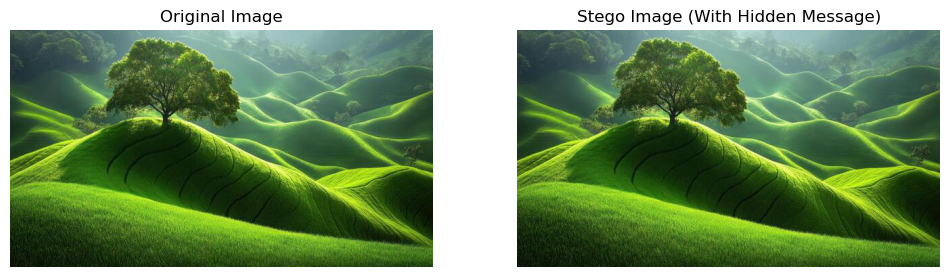

In [3]:
import matplotlib.pyplot as plt

# Load both images
original = Image.open("input_image.jpg")
stego = Image.open("random_encoded.png")

# Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(stego)
axes[1].set_title("Stego Image (With Hidden Message)")
axes[1].axis('off')

plt.show()